In [1]:
import os, sys, gc, json, random, re, copy, multiprocessing as mp
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from tqdm.auto import tqdm

from inputs import input_files_kor, input_files_uk
from module import (
    shortestpath_systemfunc,
    MCNF_systemfunc,
    safe_pi,
    evaluate_individual,
    generate_lhs_bitstrings,
    lhs_population,
    ind_to_dict,
    run_ga,
    c_of_pi,
    get_final_points,
    fmt_pdm_label,
    plot_resilience_threshold,
)

VERBOSE = True

gc.collect()
%matplotlib inline


## Load data

In [2]:
from inputs import input_files_kor, input_files_uk

REGION = "kor"  # or "kor"
input_files = input_files_kor if REGION == "kor" else input_files_uk

jload = lambda p: json.loads(Path(p).read_text(encoding="utf-8"))

nodes_raw = jload(input_files["nodes"])
nodes = {nid: (v["x"], v["y"]) for nid, v in nodes_raw.items()}
_edges = jload(input_files["edges"])
edges = {eid: (v["from"], v["to"]) for eid, v in _edges.items()}

arcs = list(edges.values())
arc_distance = {
    eid: float(v["arc_distance"])
    for eid, v in _edges.items()
    if "arc_distance" in v
}
intact_capacity = {
    eid: float(v["intact_capacity"])
    for eid, v in _edges.items()
    if "intact_capacity" in v
}
probs = {
    eid: v.get("probs", {})
    for eid, v in _edges.items()
    if "probs" in v
}

if VERBOSE:
    print(f"#nodes={len(nodes)}, #edges={len(edges)}, #arcs={len(arcs)}")
    print(f"arc_distance={len(arc_distance)}, intact_capacity={len(intact_capacity)}, probs={len(probs)}")


#nodes=79, #edges=192, #arcs=192
arc_distance=192, intact_capacity=192, probs=190


In [3]:
# Data: demand
demand_raw = jload(input_files["demand"])

demand_dict   = {}
max_distance  = {}
avg_velo      = 149.0   # km/h
delay_time    = 180.0   # minutes

for idx, item in enumerate(demand_raw, start=1):
    k = f"k{idx}"
    demand_dict[k] = {
        "origin":      item["origin_name"],
        "destination": item["destination_name"],
        "amount":      float(item["journeys"]),
        "distance":    float(item["distance"]),
    }
    extra = (avg_velo * delay_time / 60.0) * 1000.0
    max_distance[k] = demand_dict[k]["distance"] + extra

if VERBOSE:
    ex = list(demand_dict.items())[:3]
    print(f"#OD={len(demand_dict)}; examples:\n" + "\n".join(f"  {k}: {v}" for k, v in ex))

#OD=1080; examples:
  k1: {'origin': 'n4', 'destination': 'n3', 'amount': 10286.0, 'distance': 3200.0}
  k2: {'origin': 'n4', 'destination': 'n1', 'amount': 2115.0, 'distance': 9100.0}
  k3: {'origin': 'n4', 'destination': 'n2', 'amount': 7607.0, 'distance': 22000.0}


## Critical scenario prioritization
Genetic algorithm

In [4]:
# Component id list
ID_PATTERN = re.compile(r"^e(\d+)(r)?$")
COMPONENT_IDS = sorted({f"e{m.group(1)}" for k in probs for m in [ID_PATTERN.match(k)] if m}, key=lambda s: int(s[1:]))

In [5]:
# GA configuration
CASES = {
    # 1: dict(delay=30),
    # 2: dict(delay=60),
    3: dict(delay=120),
}
NUM_COMPONENTS = len(COMPONENT_IDS)
POP_SIZE = 350
NGEN = 200
CXPB = 0.7
MUTPB_DEFAULT = 1.0 / max(1, NUM_COMPONENTS)
PROCESSES = 8
MAX_STAGNANT = 20
SHOW_FRONT_DETAILS = False  # set True for per-generation prints

In [6]:
# Save path 
PROJECT_ROOT = Path.cwd().resolve()
SAVE_ROOT = PROJECT_ROOT / "outputs"
SAVE_DIR = SAVE_ROOT / REGION / "Genetic_Algorithm"
SAVE_DIR.mkdir(parents=True, exist_ok=True)

ctx = {
    "COMPONENT_IDS": COMPONENT_IDS,
    "probs": probs,
    "edges": edges,
    "intact_capacity": intact_capacity,
    "avg_velo": avg_velo,
    "demand_dict": demand_dict,
    "arcs": arcs,
    "arc_distance": arc_distance,
    "systemfunc": shortestpath_systemfunc,
}

# Run GA and save results
GA_RESULTS = {}
for cid, cfg in CASES.items():
    for sys in ("shortest",): 
        result = run_ga(
            case_id   = cid,
            delay     = cfg["delay"],
            sys_name  = sys,
            ctx       = ctx,              
            pop_size  = POP_SIZE,          
            ngen      = NGEN,           
            cxpb      = CXPB,            
            mutpb     = MUTPB_DEFAULT,      
            processes = PROCESSES,          
            max_stag  = MAX_STAGNANT,      
            seed      = 42,               
            show_front_details = SHOW_FRONT_DETAILS,  
        )
        GA_RESULTS[(cid, sys)] = result

        gens_serial = []
        for gen_idx, pop in enumerate(result["pops"]):
            pop_serial = [ind_to_dict(ind) for ind in pop]
            pareto_fits = result["paretos"][gen_idx]
            pareto_serial = [
                {"pi": float(pi), "beta": float(beta)} 
                for pi, beta in pareto_fits
            ]
            gens_serial.append(
                {"gen": gen_idx, "population": pop_serial, "pareto": pareto_serial}
            )

        out = {
            "case": cid,
            "system": sys,
            "region": REGION,
            "delay": cfg["delay"],
            "generations": gens_serial,
            "hof": [ind_to_dict(ind) for ind in result["hof"]],
        }

        if sys == "mcnf":
            fname = SAVE_DIR / f"GA_delay{cfg['delay']}_mcnf.json"
        elif sys == "shortest":
            fname = SAVE_DIR / "GA_shortest.json"
        else:
            fname = SAVE_DIR / f"GA_{sys}.json"

        with open(fname, "w", encoding="utf-8") as f:
            json.dump(out, f, indent=2)
        print(f"Saved {fname}")


▶ CASE 3 | SHORTEST (delay=120 min)


GA Case3-SHORTEST:   0%|          | 0/200 [00:00<?, ?it/s]

Early stop: unchanged 20 generations.
Saved C:\Users\Minji Kang\Documents\GitHub\railnet_opt\02_critical_scenario_prioritization\outputs\kor\Genetic_Algorithm\GA_shortest.json


plot results

Loading: C:\Users\Minji Kang\Documents\GitHub\railnet_opt\02_critical_scenario_prioritization\outputs\kor\Genetic_Algorithm\GA_shortest.json


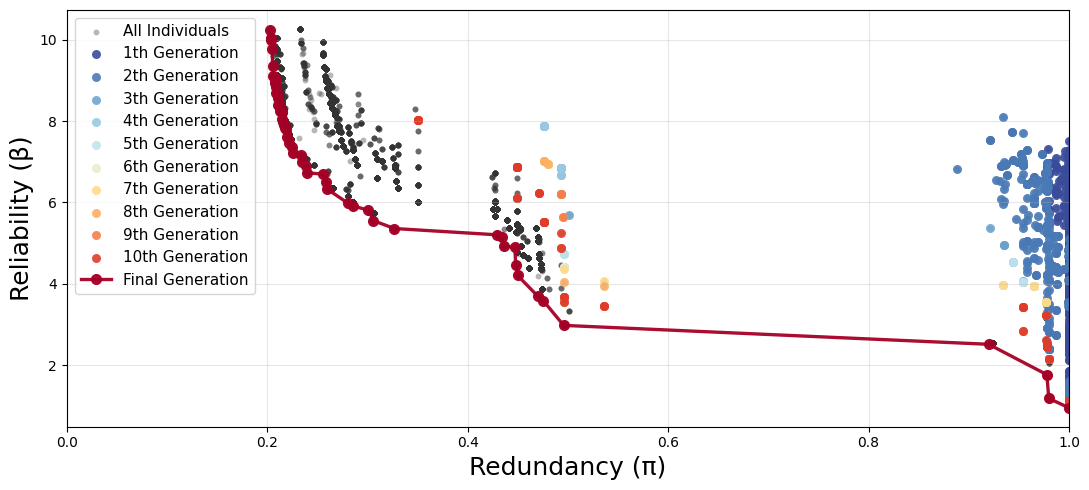

In [9]:
SYS_NAME = "shortest"      # or "mcnf"
DELAY    = 120         # only for mcnf

PROJECT_ROOT = Path.cwd().resolve()
GA_DIR = PROJECT_ROOT
RESULTS_ROOT = GA_DIR / "outputs"
RESULTS_DIR = RESULTS_ROOT / REGION / "Genetic_Algorithm"

if SYS_NAME == "mcnf":
    path = RESULTS_DIR / f"GA_delay{DELAY}_mcnf.json"
elif SYS_NAME == "shortest":
    path = RESULTS_DIR / "GA_shortest.json"
else:
    raise ValueError(f"Unknown SYS_NAME: {SYS_NAME}")

print("Loading:", path)

# Load
data = json.loads(path.read_text(encoding="utf-8"))
gens = data["generations"]

# Prepare
pop_per_gen = [
    [(float(ind["pi"]), float(ind["beta"])) for ind in g["population"]]
    for g in gens
]
pareto_per_gen = [
    [(float(p["pi"]), float(p["beta"])) for p in g.get("pareto", [])] or None
    for g in gens
]

colors = ["#394B9A","#4A7BB7","#6EA6CD","#98CAE1",
          "#C0E4EF","#EAECCC","#FEDA8B","#FEB061",
          "#F67E4B","#DD3C2C"]

# Plot
plt.figure(figsize=(11, 5))

all_pts = [pt for gen_pts in pop_per_gen for pt in gen_pts]
if all_pts:
    plt.scatter(
        [p for p, _ in all_pts],
        [b for _, b in all_pts],
        s=18,
        alpha=0.35,
        color="#333333",
        linewidths=0,
        label="All Individuals"
    )

G = min(10, len(pop_per_gen))
for gi in range(G):
    pts = pop_per_gen[gi]
    if pts:
        plt.scatter(
            [p for p, _ in pts],
            [b for _, b in pts],
            s=42,
            alpha=0.9,
            color=colors[gi],
            linewidths=0,
            label=f"{gi+1}th Generation"
        )

final_idx = len(pop_per_gen) - 1
final_pts = pop_per_gen[final_idx]
final_pareto = pareto_per_gen[final_idx]

if final_pareto and len(final_pareto) >= 2:
    xs = [p for p, _ in final_pareto]
    ys = [b for _, b in final_pareto]
else:
    final_sorted = sorted(final_pts, key=lambda x: x[1])
    xs = [p for p, _ in final_sorted]
    ys = [b for _, b in final_sorted]

if xs and ys:
    plt.plot(
        xs, ys,
        "-o",
        color="#A50026",
        markersize=7,
        linewidth=2.4,
        alpha=0.95,
        label="Final Generation"
    )

plt.xlabel("Redundancy (π)", fontsize=18)
plt.ylabel("Reliability (β)", fontsize=18)
plt.xlim(0, 1.0)

if all_pts:
    b_min = min(b for _, b in all_pts)
    b_max = max(b for _, b in all_pts)
    if b_max > b_min:
        pad = 0.05 * (b_max - b_min)
        plt.ylim(b_min - pad, b_max + pad)

plt.grid(True, alpha=0.3)
plt.legend(fontsize=11, loc="best")
plt.tight_layout()
plt.show()


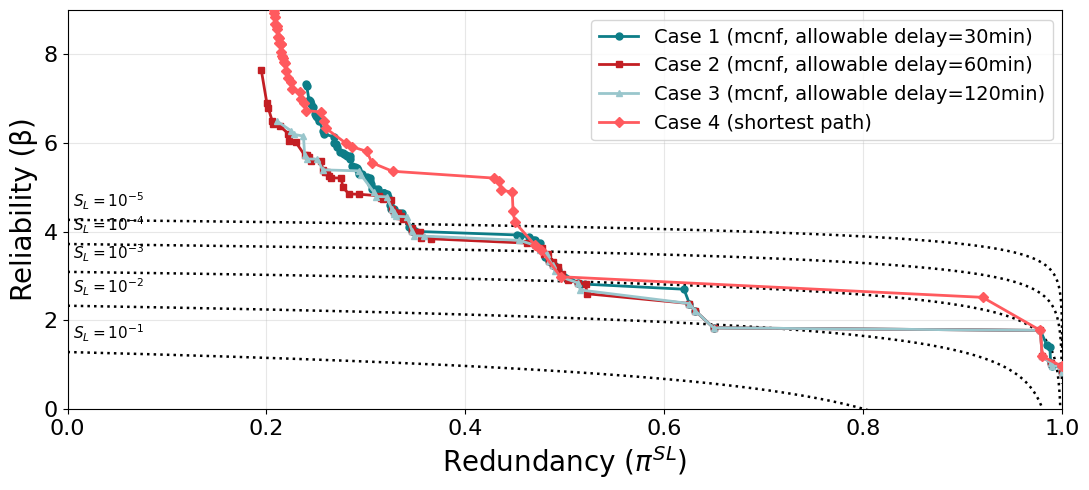

In [11]:
PROJECT_ROOT = Path.cwd().resolve()
base_dir = PROJECT_ROOT / "outputs" / REGION / "Genetic_Algorithm"  

files = [
    ("Case 1 (mcnf, allowable delay=30min)",  base_dir / "GA_delay30_mcnf.json"),
    ("Case 2 (mcnf, allowable delay=60min)",  base_dir / "GA_delay60_mcnf.json"),
    ("Case 3 (mcnf, allowable delay=120min)", base_dir / "GA_delay120_mcnf.json"),
    ("Case 4 (shortest path)",               base_dir / "GA_shortest.json"),
]

styles = [
    dict(color="#0d7d87", marker="o", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
    dict(color="#c31e23", marker="s", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
    dict(color="#99c6cc", marker="^", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
    dict(color="#ff5a5e", marker="D", linestyle="-", linewidth=2.0, markersize=5, zorder=3),
]

# Resilience threshold
DRAW_ISORISK = True
LAMBDA = 1.0
PDM_LIST = [1e-1, 1e-2, 1e-3, 1e-4, 1e-5]
C_MODE = "one_minus_pi"
LABEL_X_RANGE = (0.00500, 0.0250)

# Plot
plt.figure(figsize=(11, 5))
ax = plt.gca()

any_points = False
for (label, path), st in zip(files, styles):
    if not path.exists():
        print(f"[WARN] missing: {path}")
        continue
    pts = get_final_points(path)
    if not pts:
        print(f"[WARN] no points: {path}")
        continue
    xs = [p for p, _ in pts]
    ys = [b for _, b in pts]
    ax.plot(xs, ys, label=label, **st)
    any_points = True

if not any_points:
    raise RuntimeError("No data to plot. Check file paths.")

ax.set_xlabel(r"Redundancy ($\pi^{SL}$)", fontsize=20)
ax.set_ylabel("Reliability (β)", fontsize=20)
ax.tick_params(axis="x", labelsize=16)
ax.tick_params(axis="y", labelsize=16)
ax.set_xlim(0, 1.0)
ax.set_ylim(0.0, 9)
ax.grid(True, alpha=0.3)

if DRAW_ISORISK:
    for pdm in sorted(PDM_LIST, reverse=True):
        plot_resilience_threshold(
            ax, pdm=pdm, lambda_=LAMBDA, c_mode=C_MODE,
            pi_lo=ax.get_xlim()[0],
            pi_hi=min(0.9999, ax.get_xlim()[1]),
            label_x_range=LABEL_X_RANGE,
        )

ax.legend(fontsize=14, loc="upper right")
plt.tight_layout()
plt.show()
